In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/PedroGirotto/dataset_estatistica/refs/heads/main/aula01_intro/data.csv"
df = pd.read_csv(url)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [26]:
matematica70 = df["math score"] >= 70
redacao70 = df["writing score"] >= 70
texto70 = df["reading score"] >= 70
aprovados = df[(matematica70) & (redacao70) & (texto70)]
aprovados

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
2,female,group B,master's degree,standard,none,90,95,93
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
...,...,...,...,...,...,...,...,...
984,female,group C,some high school,standard,none,74,75,82
987,male,group E,some high school,standard,completed,81,75,76
990,male,group E,high school,free/reduced,completed,86,81,75
995,female,group E,master's degree,standard,completed,88,99,95


In [25]:
rematematica70 = df["math score"] < 70
reredacao70 = df["writing score"] < 70
retexto70 = df["reading score"] < 70
reprovados = df[(rematematica70) & (reredacao70) & (retexto70)]
reprovados

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
3,male,group A,associate's degree,free/reduced,none,47,57,44
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50
10,male,group C,associate's degree,standard,none,58,54,52
...,...,...,...,...,...,...,...,...
985,male,group A,high school,standard,none,57,51,54
986,female,group C,associate's degree,standard,none,40,59,51
988,female,group A,some high school,free/reduced,none,44,45,45
994,male,group A,high school,standard,none,63,63,62


In [ ]:
aprovados["math score"].mean()

np.float64(81.78)

<Axes: xlabel='math score', ylabel='Count'>

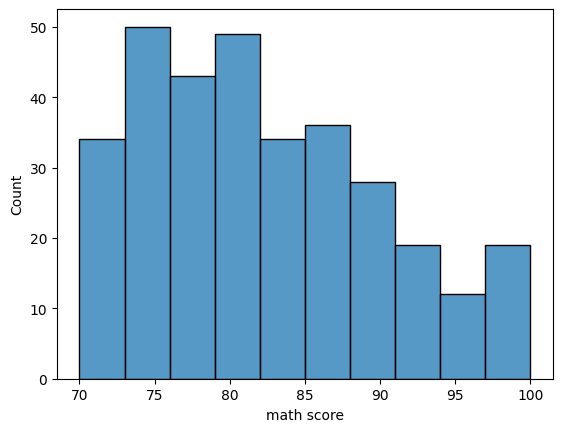

In [32]:
sns.histplot(data=aprovados, x="math score")

In [34]:
reprovados["math score"].mean()

np.float64(52.94235588972431)

<Axes: xlabel='math score', ylabel='Count'>

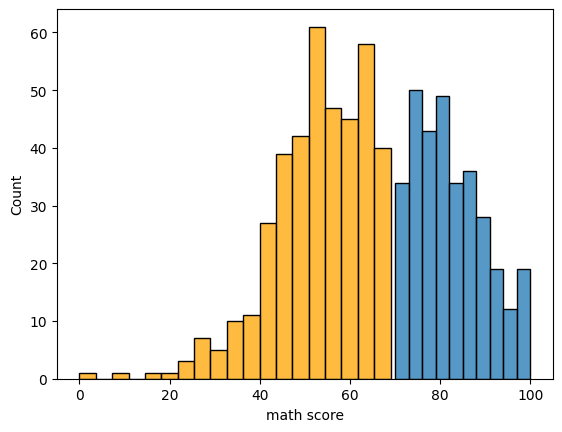

In [35]:
sns.histplot(data=aprovados, x="math score")
sns.histplot(data=reprovados, x="math score", color="orange")

In [36]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [38]:
df["test preparation course"].unique()

array(['none', 'completed'], dtype=object)

In [41]:
df[df["test preparation course"] == "none"]["math score"].mean()

np.float64(64.0778816199377)

In [42]:
df[df["test preparation course"] == "completed"]["math score"].mean()

np.float64(69.69553072625699)

In [55]:
df.groupby("test preparation course")[["math score","writing score","reading score"]].mean()

,math score,writing score,reading score
test preparation course,,,
completed,69.695531,74.418994,73.893855
none,64.077882,64.504673,66.534268


In [56]:
df.groupby("lunch")[["math score","writing score","reading score"]].mean()

,math score,writing score,reading score
lunch,,,
free/reduced,58.921127,63.022535,64.653521
standard,70.034109,70.823256,71.654264


In [58]:
pd.crosstab(df["race/ethnicity"], df["lunch"])

lunch,free/reduced,standard
race/ethnicity,,
group A,36,53
group B,69,121
group C,114,205
group D,95,167
group E,41,99


<Axes: xlabel='math score', ylabel='Count'>

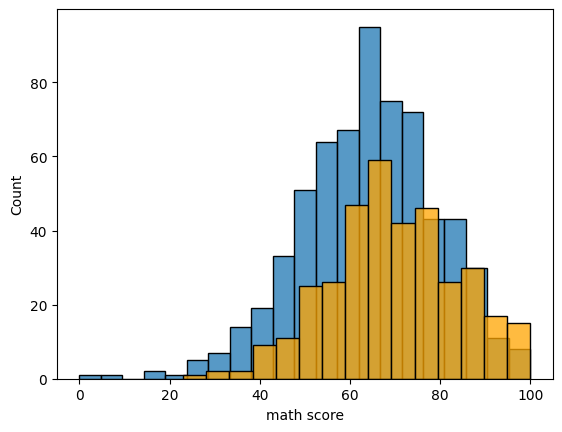

In [43]:
sns.histplot(data=df[df["test preparation course"] == "none"], x="math score")
sns.histplot(data=df[df["test preparation course"] == "completed"], x="math score", color="orange")

In [45]:
df[(df["math score"]>=100) & (df["reading score"]>=100) & (df["writing score"]>=100)]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
458,female,group E,bachelor's degree,standard,none,100,100,100
916,male,group E,bachelor's degree,standard,completed,100,100,100
962,female,group E,associate's degree,standard,none,100,100,100
